In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv('orders.csv', sep=';')

print(df.head())

  Country     Seller   OrderDate  OrderId  OrderValue
0  Polska   Kowalski  2003-07-16    10248      440.00
1  Polska   Sowiński  2003-07-10    10249     1863.40
2  Niemcy    Peacock  2003-07-12    10250     1552.60
3  Niemcy  Leverling  2003-07-15    10251      654.06
4  Niemcy    Peacock  2003-07-11    10252     3597.90


In [26]:
import numpy as np

# 1.1 
print(df.isna().sum())

# 1.2 
seller_indices = df_missing.sample(frac=0.1).index
df_missing.loc[seller_indices, 'Seller'] = 'MISSING'

# 1.3 
orderid_indices = df_missing.sample(frac=0.05).index
df_missing.loc[orderid_indices, 'OrderId'] = np.nan

# 1.4 
orderdate_indices = df_missing.sample(frac=0.20).index
df_missing.loc[orderdate_indices, 'OrderDate'] = np.nan

# 1.5 
ordervalue_indices = df_missing.sample(frac=0.15).index
df_missing.loc[ordervalue_indices, 'OrderValue'] = np.nan

# 1.6 
df_missing = df.copy()

Country       0
Seller        0
OrderDate     0
OrderId       0
OrderValue    0
dtype: int64


In [27]:
# 2.1 
df_missing['OrderId'] = df_missing['OrderId'].fillna(0)

# 2.2 
df_missing['OrderDate'] = df_missing['OrderDate'].ffill()

# 2.3 
df_missing['OrderValue'] = df_missing['OrderValue'].fillna(df_missing.groupby('Country')['OrderValue'].transform('mean'))

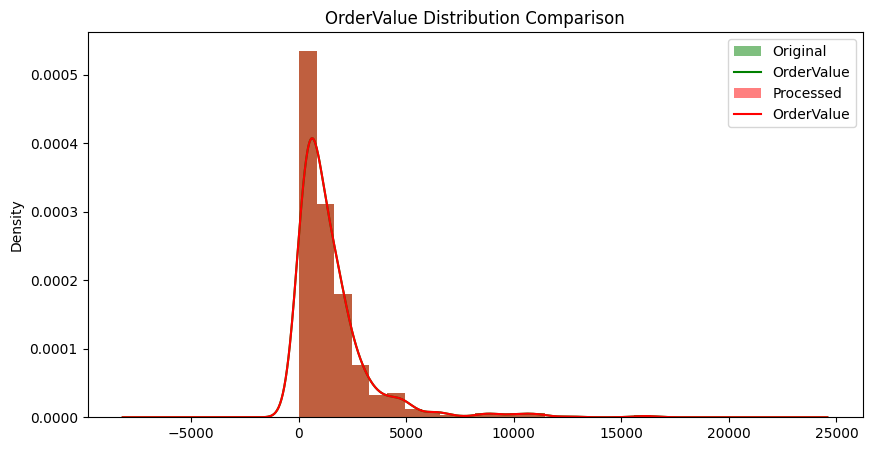

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
df['OrderValue'].hist(bins=20, alpha=0.5, label='Original', density=True, color='green')
df['OrderValue'].plot.density(color='green')

df_missing['OrderValue'].hist(bins=20, alpha=0.5, label='Processed', density=True, color='red')
df_missing['OrderValue'].plot.density(color='red')

plt.legend()
plt.title('OrderValue Distribution Comparison')
plt.show()

In [29]:
# 4.1 
print(df.groupby('Country')['OrderValue'].mean())

df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# 4.2 
print(df.groupby([df['OrderDate'].dt.year, df['OrderDate'].dt.month])['OrderValue'].mean())

# 4.4 
top_sellers = df.groupby(['Country', 'Seller'])['OrderValue'].sum().reset_index()
print(top_sellers.sort_values('OrderValue', ascending=False).drop_duplicates('Country'))

Country
Niemcy    1532.528236
Polska    1550.376326
Name: OrderValue, dtype: float64
OrderDate  OrderDate
2003       7            1218.251176
           8            1097.598696
           9             858.577143
           10           1456.390000
           11           1973.045000
           12           1443.086875
2004       1            1914.425000
           2            1164.535926
           3            1484.822187
           4            1053.214667
           5            1999.229687
           6            1669.432667
           7            1211.127097
           8            1562.998889
           9            1329.139737
           10           2064.032778
           11           1123.419722
           12           1632.980000
2005       1            1487.635357
           2            2132.384815
           3            1157.157910
           4            1931.107297
           5            1155.370000
Name: OrderValue, dtype: float64
  Country   Seller  OrderValue
4 